Retail Sales Analysis and Prediction

**Title of ML project**: Retail Sales Analysis and Prediction

**Name:** Anil R Pai

**Organization:** Entri Elevate

**Date:** 27-5-2026

**Domain:** Retail Sector

**Overview of Problem Statement:**


Retail businesses generate massive amounts of transactional data every day but raw sales data is often incomplete, inconsistent,and difficult to use directly for decision-making. Poor data quality can lead to inaccurate reporting, weak forecasting, and inefficient business strategies. This project aims to Machine Learning to analyze retail sales patterns and predict total sales (Total Spent).

In [ ]:
**Data Collection:**

**Data Description:**

- Source:

Kaggle Retail Store Sales Dataset
(File used: retail_store_sales.csv)

- Features:

Columns:

Transaction ID,
Customer ID,
Category,
Item,
Price Per Unit,
Quantity,
Total Spent,
Payment Method,
Location,
Transaction Date,
Discount Applied

**Data Collection:**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("retail_store_sales.csv")

# View the first 5 rows to see feature patterns
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Check the dimensions of the data
print ("\nDimensions of the dataset:")
print(df.shape)

# Dataset Information
print("\nDataset Information:")
display(df.info())

# Statistical Summary
print("\nStatistical Overview of Numerical Features:")
display(df.describe())
#print(df.isnull().sum())




First 5 rows of the dataset:


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False



Dimensions of the dataset:
(12575, 11)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


None


Statistical Overview of Numerical Features:


,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


**Data Preprocessing - Data Cleaning:**

In [8]:
# Check for missing values in each column
print(df.isnull().sum())

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64


In [9]:
#Handling Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)

In [10]:
df.drop_duplicates(inplace=True)
print(df.shape)

(12575, 11)


In [11]:
#Handling Missing Values

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df.fillna({col: df[col].median()}, inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df.fillna({col:df[col].mode()[0]}, inplace=True)

# Remove Outliers using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

# Handle Skewness
from scipy.stats import skew

for col in num_cols:
    if abs(skew(df[col])) > 1:
        df[col] = np.log1p(df[col])


print("Preprocessing Complete: Missing values handled, outliers capped, and skewness reduced.")
    

Preprocessing Complete: Missing values handled, outliers capped, and skewness reduced.


C:\Users\DELL WIN\AppData\Local\Temp\ipykernel_10996\2848458949.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna({col:df[col].mode()[0]}, inplace=True)


**Exploratory Data Analysis (EDA):**

Histogram

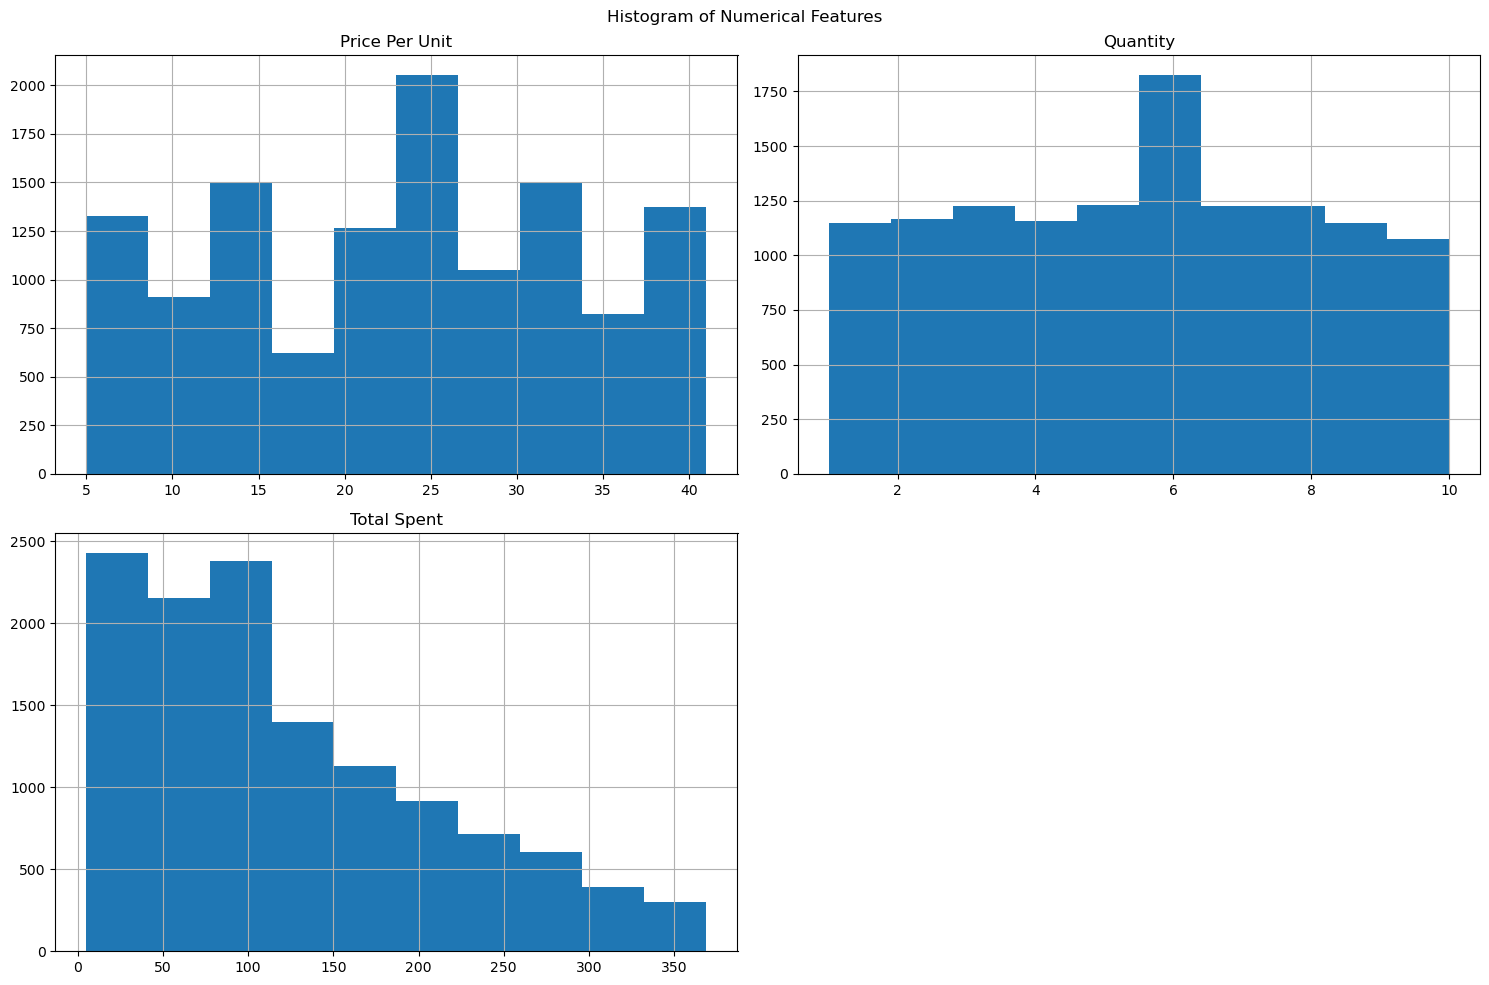

In [12]:
df[num_cols].hist(figsize=(15,10))
plt.suptitle("Histogram of Numerical Features")
plt.tight_layout()
plt.show()

Boxplot

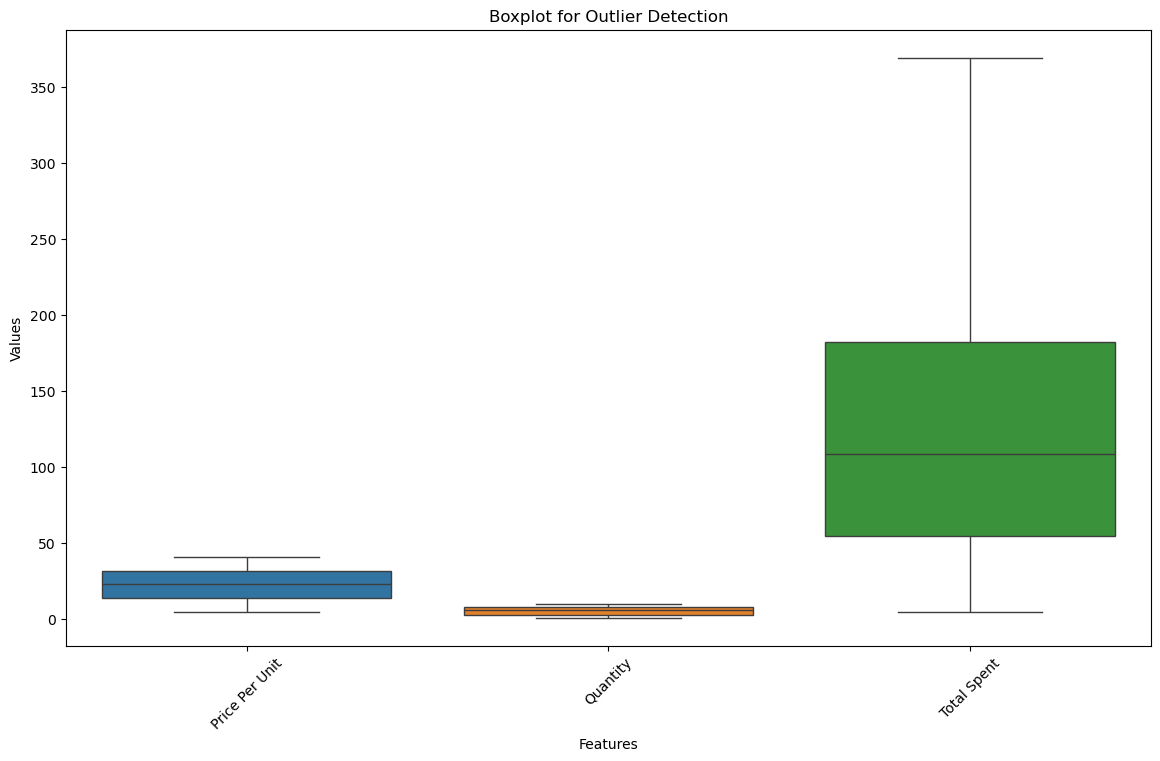

In [13]:
plt.figure(figsize=(14,8))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Values")
plt.show()

Pairplot

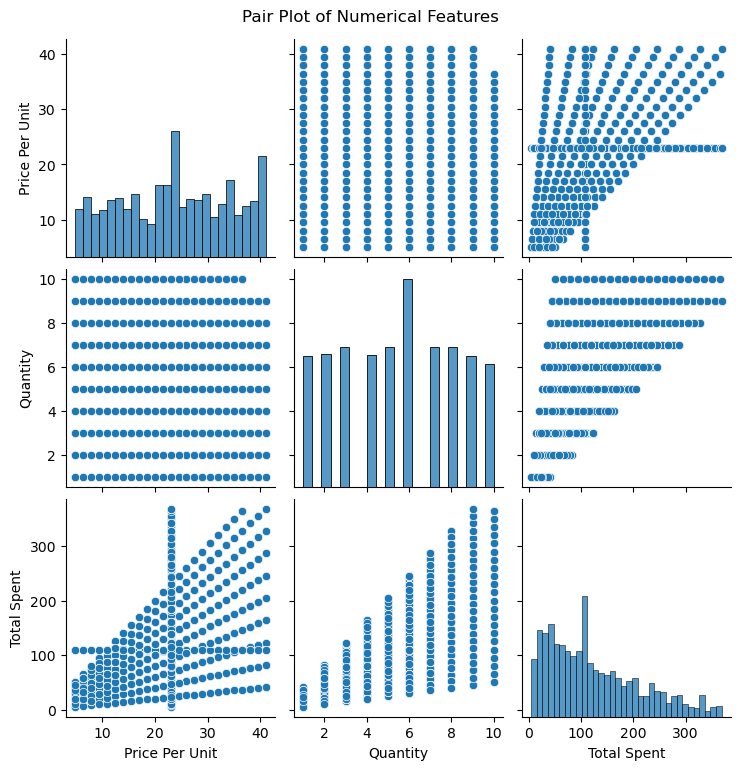

In [14]:
sns.pairplot(df[num_cols])
plt.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()

Heatmap Correlation

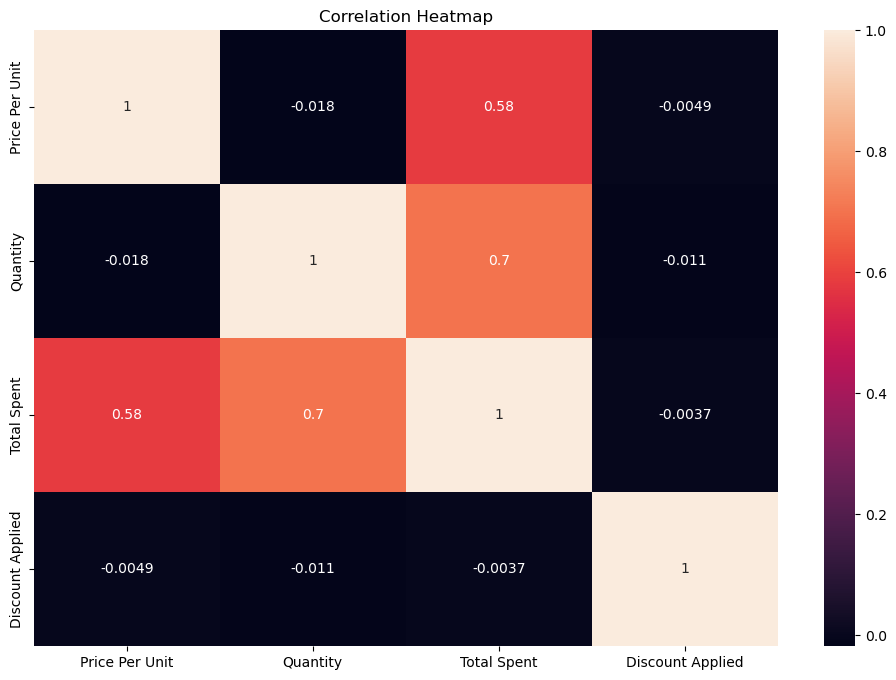

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Pie Diagram

Text(0, 0.5, '')

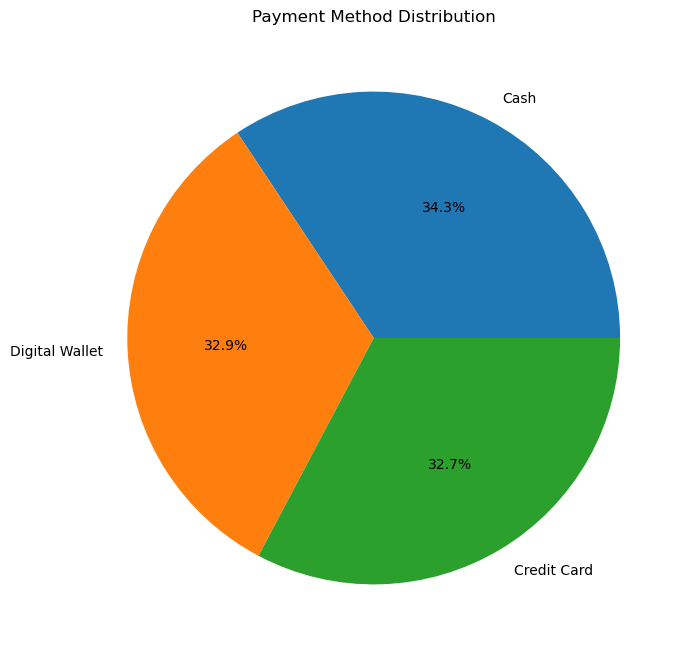

In [16]:
df['Payment Method'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(8,8)
)
plt.title("Payment Method Distribution")
plt.ylabel("")

Bar Plot

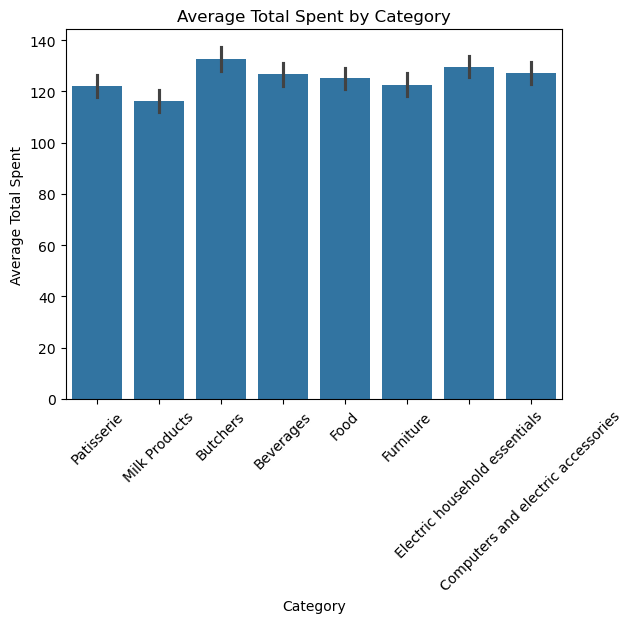

In [17]:
sns.barplot(x='Category', y='Total Spent', data=df)
plt.title("Average Total Spent by Category")
plt.xlabel("Category")
plt.ylabel("Average Total Spent")
plt.xticks(rotation=45)
plt.show()

In [ ]:
Count Plot

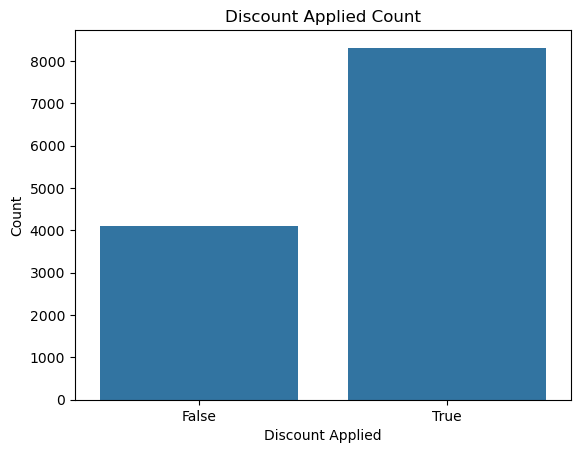

In [18]:
sns.countplot(x='Discount Applied', data=df)
plt.title("Discount Applied Count")
plt.xlabel("Discount Applied")
plt.ylabel("Count")
plt.show()

Line Plot

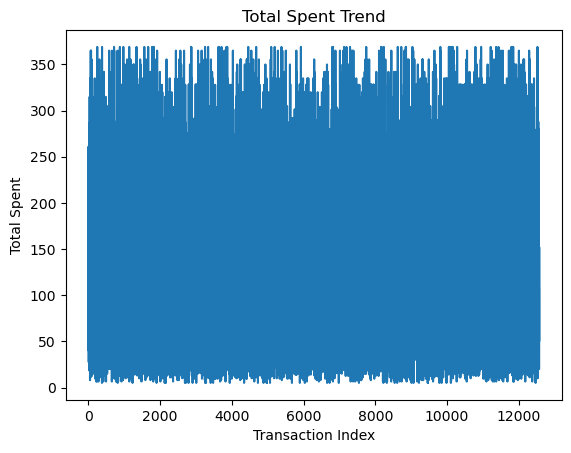

In [19]:
sns.lineplot(x=df.index, y='Total Spent', data=df)
plt.title("Total Spent Trend")
plt.xlabel("Transaction Index")
plt.ylabel("Total Spent")
plt.show()

Kernel Density Estimation (KDE)

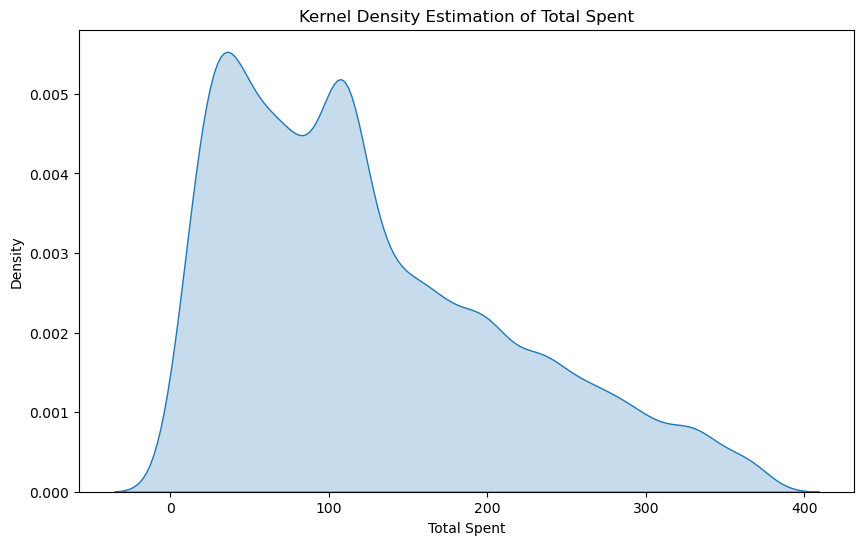

In [20]:
plt.figure(figsize=(10,6))
sns.kdeplot(df['Total Spent'], fill = True)
plt.title("Kernel Density Estimation of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Density")
plt.show()

**Feature Engineering:**

Identification of Categorical Features

Scanning the dataset for any columns that are "Object" types (text) or "Categorical" (labels).

In [21]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

df['Year'] = df['Transaction Date'].dt.year
df['Month'] = df['Transaction Date'].dt.month
df['Day'] = df['Transaction Date'].dt.day
df['Weekday'] = df['Transaction Date'].dt.weekday
df['Quarter'] = df['Transaction Date'].dt.quarter
df['Is_Weekend'] = df['Weekday'].isin([5,6]).astype(int)

df.drop('Transaction Date', axis=1, inplace=True)

In [22]:
# Identify categorical columns (Object type)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Features found: {categorical_cols}")

Categorical Features found: ['Transaction ID', 'Customer ID', 'Category', 'Item', 'Payment Method', 'Location']


**Encoding Techniques**

Label Encoding:

Converts categories into numbers (e.g., Low=0, Medium=1, High=2). Best for Ordinal data where order matters.

One-Hot Encoding:

Creates new columns for each category with 1s and 0s. Best for Nominal data where there is no specific order.

In [23]:
from sklearn.preprocessing import LabelEncoder

# A. Remove Constant Features (Features that have the same value for every row)
constant_features = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_features, inplace=True, errors='ignore')
print(f"Dropped {len(constant_features)} redundant constant columns.")

# B. Handle Categorical Features
# If the dataset has text-based columns
if len(categorical_cols) > 0:
    le = LabelEncoder()
    for col in categorical_cols:
     # if col != 'Transaction Date':
        df[col] = le.fit_transform(df[col])

    print("Categorical features encoded successfully.")
else:
    print("No categorical features found; all features are already numerical.")

# C. Final Verification
print(f"Final dataset shape after Feature Engineering: {df.shape}")

Dropped 0 redundant constant columns.
Categorical features encoded successfully.
Final dataset shape after Feature Engineering: (12418, 16)


**Feature Selection:**

In [24]:
X = df.drop('Total Spent', axis=1)
y = df['Total Spent']

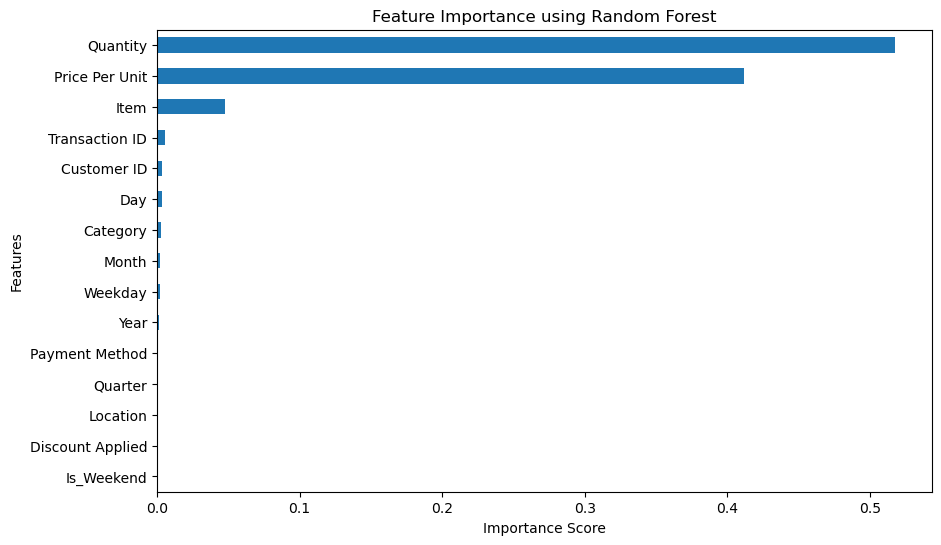

In [25]:
# Random Forrest
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import matplotlib.pyplot as plt


# Train Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Feature Importance
importance = pd.Series(rf.feature_importances_, index=X.columns)

# Plot Importance
plt.figure(figsize=(10,6))
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance using Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

In [26]:
# SelectKBest

from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=8)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['Category', 'Item', 'Price Per Unit', 'Quantity', 'Payment Method',
       'Location', 'Weekday', 'Is_Weekend'],
      dtype='object')


**Split Data into Training and Testing Sets:**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X[selected_features],
    y,
    test_size=0.2,
    random_state=42
)
print("Summary:")
print(f"Total samples: {len(df)}")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Summary:
Total samples: 12418
Training set: 9934 samples
Testing set: 2484 samples


**Feature Scaling**

In [28]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# 1. Fit and transform the training data
X_train = scaler.fit_transform(X_train)

# 2. Only transform the testing data (using the mean/std from the training set)
X_test = scaler.transform(X_test)

print("Complete: Features scaled to uniform magnitude.")
print(f"Mean of scaled training data: {X_train.mean():.2f}")
print(f"Standard deviation of scaled training data: {X_train.std():.2f}")

Complete: Features scaled to uniform magnitude.
Mean of scaled training data: 0.00
Standard deviation of scaled training data: 1.00


**Build the ML Model**

In [30]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression

# Initialize the 5 Regression Models
models = {
    "Linear Regression": LinearRegression(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boost": GradientBoostingRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42)
}

# Training Loop
print("Starting model training...")

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Successfully trained: {name}")

print("\nAll 5 models are now built and trained on scaled dataset.")

Starting model training...
Successfully trained: Linear Regression
Successfully trained: SVR
Successfully trained: Random Forest
Successfully trained: Gradient Boost
Successfully trained: AdaBoost

All 5 models are now built and trained on scaled dataset.


In [ ]:
**Model Evaluation**

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    
    results[name] = [mae, mse, rmse, r2]

results_df = pd.DataFrame(
    results,
    index=['MAE','MSE','RMSE','R2']
).T

print(results_df)

                         MAE          MSE       RMSE        R2
Linear Regression  25.512126  1243.815020  35.267762  0.842321
SVR                13.902597   694.285124  26.349291  0.911985
Random Forest       3.376467   349.913018  18.705962  0.955641
Gradient Boost      5.657046   290.230285  17.036146  0.963207
AdaBoost           20.877829   846.586494  29.096159  0.892678


**Hyperparameter Tuning and pipeline:**

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

#Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor())
])

params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 10, None]
}

#Grid Search

grid = GridSearchCV(pipeline, params, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 200}
Best Score: 0.9715953037818121


**Save the Model**

In [35]:
import joblib

best_model = grid.best_estimator_

joblib.dump(best_model, "retail_store_sales.pkl")
print("Model Saved as retail_store_sales.pkl")

Model Saved as retail_store_sales.pkl


**Test with unseen Data**

In [36]:
loaded_model = joblib.load('retail_store_sales.pkl')

print("Saved model loaded successfully!")

Saved model loaded successfully!


Model Performance on Unseen Data
----------------------------------
MSE : 846.5864937920929
RMSE: 29.096159433713808
R2 Score: 0.8926777719918159
   Actual Values  Predicted Values
0          180.0        214.169942
1          301.5        303.948634
2           25.0         66.589272
3          215.0        177.298073
4           21.5         34.801370
5          167.5        159.125631
6          112.0         98.066339
7          167.5        159.125631
8           87.5         90.932692
9          210.0        185.106372


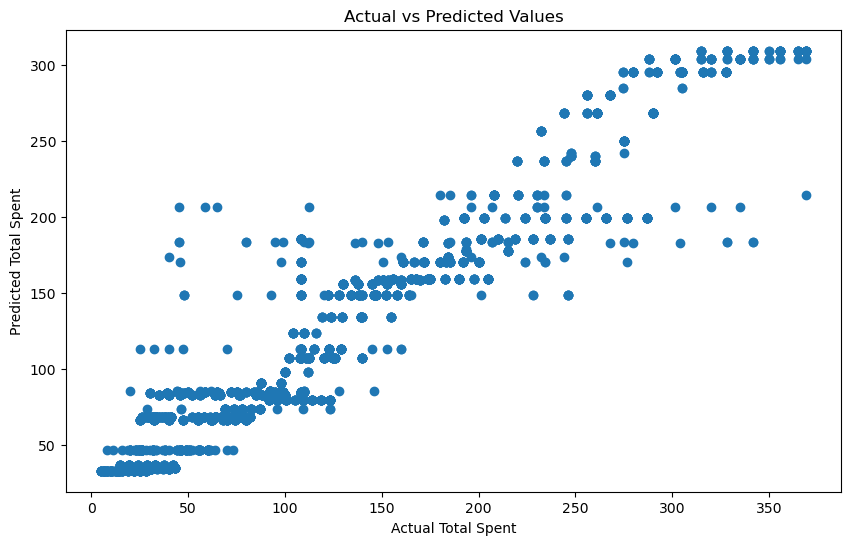

Training Score: 0.9835270250321941
Testing Score : 0.9636193975912901
Generalization Gap: 0.01990762744090402
Model Generalizes Well


In [37]:
from sklearn.metrics import accuracy_score

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print("Model Performance on Unseen Data")
print("----------------------------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

import pandas as pd

comparison = pd.DataFrame({
    'Actual Values': y_test[:10].values,
    'Predicted Values': preds[:10]
})

print(comparison)


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(y_test, preds)
plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Total Spent")
plt.ylabel("Predicted Total Spent")
plt.show()

train_score = loaded_model.score(X_train, y_train)
test_score = loaded_model.score(X_test, y_test)

print("Training Score:", train_score)
print("Testing Score :", test_score)

gap = train_score - test_score
print("Generalization Gap:", gap)

if gap > 0.05:
    print("Possible Overfitting Detected")
else:
    print("Model Generalizes Well")


**Interpretation of Results (Conclusion):**

The best model is selected based on highest R² score. Random Forest achieved highest R² score
Data cleaning improved prediction quality
Feature engineering enhanced performance
Small train-test gap indicates good generalization

**Future Work**

Proposing improvements for the next iteration of the project.

Using Deep Learning

TensorFlow / LSTM for time-series sales prediction

Periodic Retraining - Update with new retail transactions
